# Task 5 - Sales Prediction Using Python

This notebook predicts product sales from advertising spend across TV, Radio, and Newspaper channels.

In [1]:
import os
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

## Load the dataset

In [2]:
data_dir = Path.cwd() / 'data'
if not data_dir.is_dir():
    data_dir = Path.cwd().parent / 'data'

candidate_files = [data_dir / 'Advertising.csv', data_dir / 'advertising.csv', data_dir / 'sales_advertising.csv']
source = next((file for file in candidate_files if file.is_file()), None)

if source is None:
    url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
    df = pd.read_csv(url)
    source = url
else:
    df = pd.read_csv(source)

print('Loaded from:', source)
df.head()

Loaded from: C:\Users\Angad\OIBSIP\OIBSIP_DataScience_task5\data\Advertising.csv


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.columns = [col.strip().lower() for col in df.columns]
if 'unnamed: 0' in df.columns:
    df = df.drop(columns='unnamed: 0')

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())

df.describe()

Shape: (200, 4)

Missing values:
tv           0
radio        0
newspaper    0
sales        0
dtype: int64


,tv,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Exploratory analysis

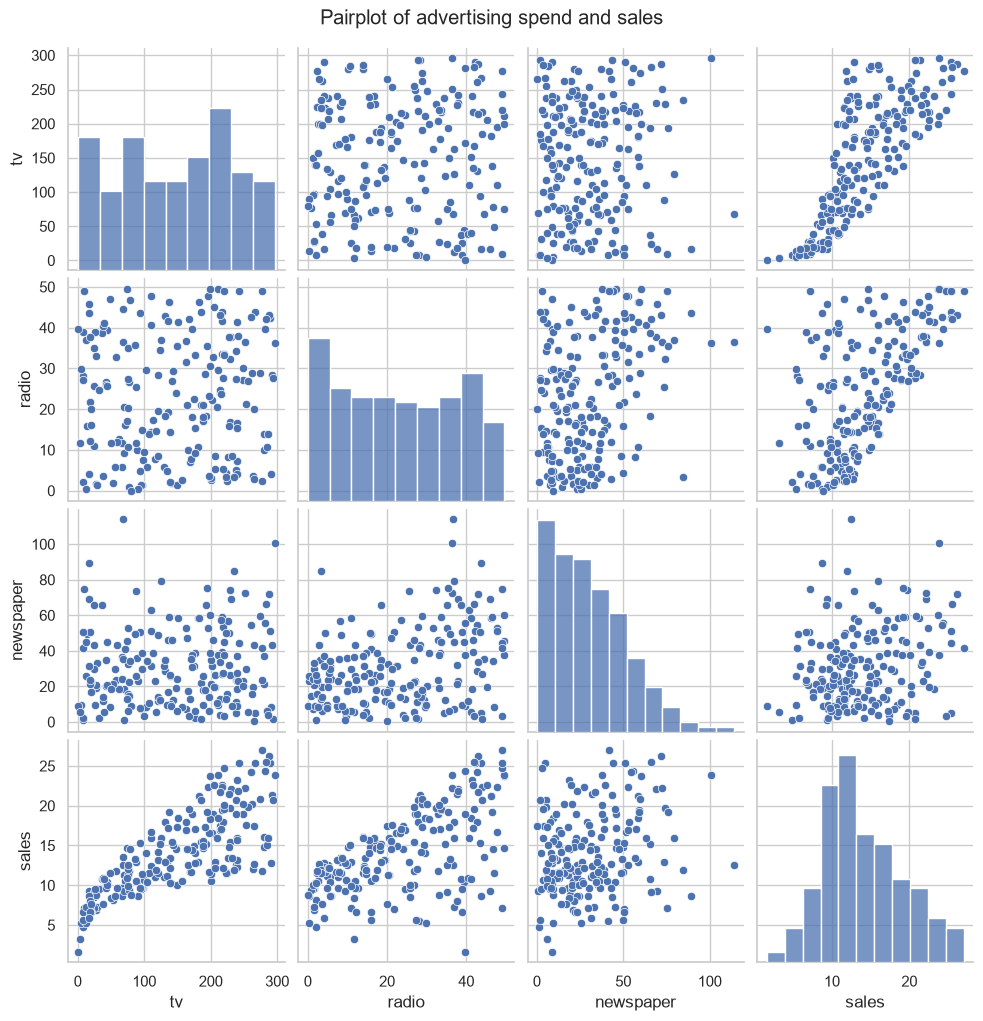

In [4]:
sns.pairplot(df)
plt.suptitle('Pairplot of advertising spend and sales', y=1.02)
plt.show()

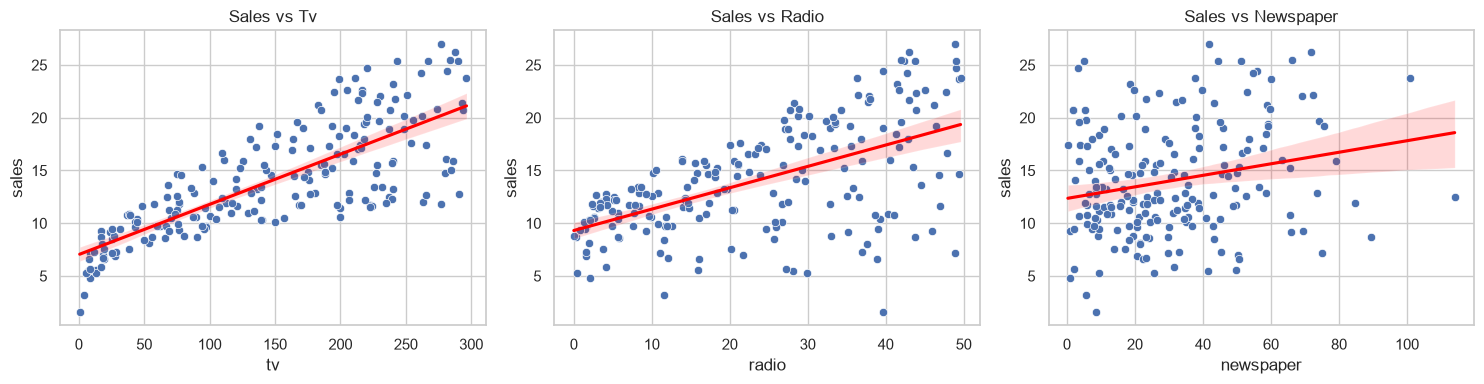

In [5]:
channels = ['tv', 'radio', 'newspaper']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, channel in zip(axes, channels):
    sns.scatterplot(data=df, x=channel, y='sales', ax=ax)
    sns.regplot(data=df, x=channel, y='sales', scatter=False, ax=ax, color='red')
    ax.set_title(f'Sales vs {channel.title()}')
plt.tight_layout()
plt.show()

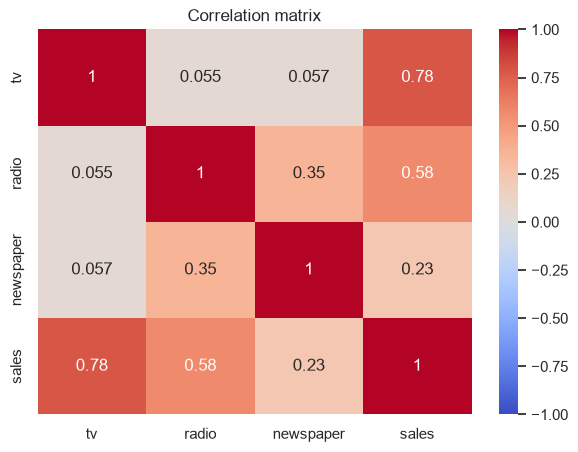

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

TV and Radio usually show the strongest relationship with sales. Newspaper spend is often weaker in this dataset.

## Model training

In [7]:
import numpy as np

X = df[['tv', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ]),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42)
}

rows = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })
    fitted_models[name] = model

results = pd.DataFrame(rows).sort_values('R2', ascending=False)
results

,Model,MAE,RMSE,R2
1,Polynomial Regression,0.526179,0.642581,0.986918
2,Random Forest,0.618133,0.752224,0.982073
0,Linear Regression,1.460757,1.781600,0.899438


## Residual plot for best model

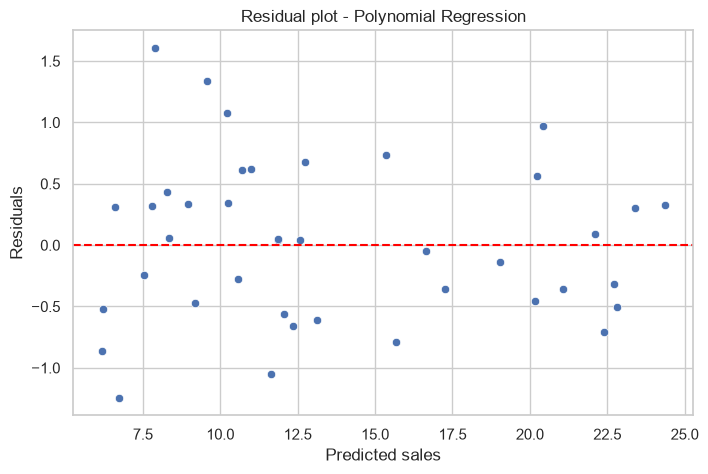

Best model: Polynomial Regression


In [8]:
best_name = results.iloc[0]['Model']
best_model = fitted_models[best_name]
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Residual plot - {best_name}')
plt.xlabel('Predicted sales')
plt.ylabel('Residuals')
plt.show()

print('Best model:', best_name)

If the residuals are scattered randomly around zero, the model is capturing the main relationship. A visible curve or funnel shape would suggest a missing pattern.

## Channel impact

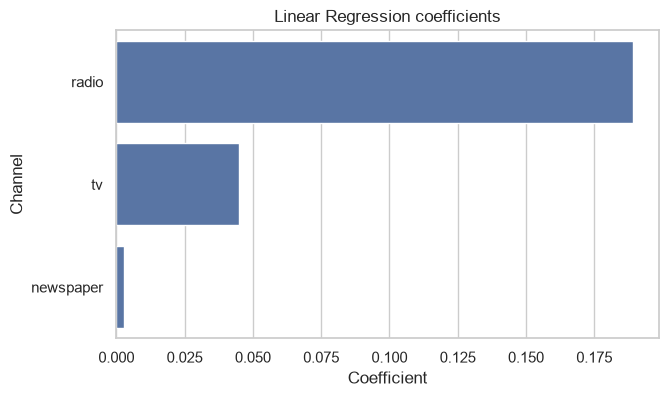

,channel,coefficient
1,radio,0.189195
0,tv,0.044730
2,newspaper,0.002761


In [9]:
linear_model = fitted_models['Linear Regression']
coef_df = pd.DataFrame({'channel': X.columns, 'coefficient': linear_model.coef_}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=coef_df, x='coefficient', y='channel')
plt.title('Linear Regression coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Channel')
plt.show()

coef_df

## Conclusion

Based on the coefficient comparison, Radio and TV usually have the strongest positive impact on sales. Newspaper is typically weaker, so a business may get better returns by prioritising TV and Radio spend.